# Function 3 Analysis - Week 3

This notebook contains the exploratory analysis for **Function 3** in Week 3. We now work with **12 datapoints**, integrating the last two weeks' queries into the dataset, and continue to rely on Bayesian optimisation for guidance.

**Function Description:** 	
You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine. Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array. Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 


## Loading and Displaying the Data

We load the inputs and outputs for function 3 and display them in a table format to inspect the raw data values. All inputs remain standardised in [0,1] and we still have the same x3 outlier, but now we also observe how the new Week 2 point behaves: despite pushing x3 higher while keeping x1 and x2 in roughly the same “good” region, it only delivered a very average (slightly negative) reward. In other words, last week’s more exploratory move did not buy us much improvement and mostly confirmed how noisy and flat this transformed objective can be in that part of the space.


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_3")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1 and Week 2 new points
X_new_point_week_1 = np.array([[0.403500, 0.382200, 0.489400]])
y_new_point_week_1 = np.array([-0.011750816624169894])
X_new_point_week_2 = np.array([[0.500000, 0.500000, 0.650000]])
y_new_point_week_2 = np.array([-0.09608263621357674])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2])

df = pd.DataFrame(X, columns=["x1", "x2", "x3"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


df sorted by y


,x1,x2,x3,y
0,0.403500,0.382200,0.489400,-0.011751
1,0.492581,0.611593,0.340176,-0.034835
2,0.600097,0.725136,0.066089,-0.036378
3,0.220549,0.297825,0.343555,-0.046947
4,0.134622,0.219917,0.458206,-0.048008
5,0.965995,0.861120,0.566829,-0.056758
6,0.242114,0.644074,0.272433,-0.087963
7,0.170477,0.697032,0.149169,-0.094190
8,0.500000,0.500000,0.650000,-0.096083
9,0.666014,0.671985,0.246295,-0.105965


- **New point (Week 1):** The `(~0.40, ~0.38, ~0.49)` query produced the best output yet at -0.011751.
- **New point (Week 2):** The `(0.50, 0.50, 0.65)` query — chosen to explore a higher x3 while keeping x1 and x2 near the apparent ridge — came back at around -0.096, which is very average compared to our best point. It suggests that simply cranking up x3 in that neighbourhood does not unlock a dramatically better regime.


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, and y). This helps identify linear relationships. We note a high correlation between x1 and x2. We will see later that there is a line of high output points when x1 and x2 are similar in magnitude. 


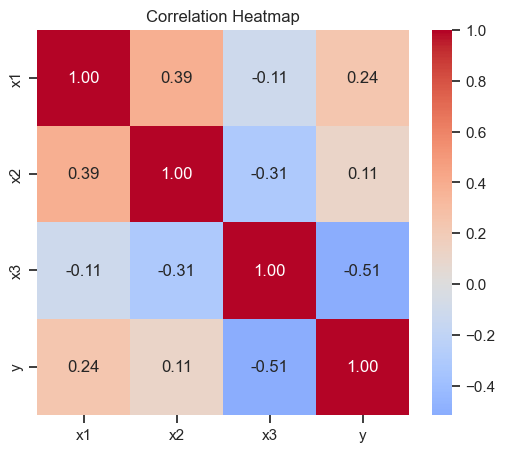

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()  

## Bayesian optimisation (expected improvement)

We use the **expected improvement (EI)** acquisition function to balance exploitation with the magnitude of potential gains. EI converts the GP posterior (mean `μ`, std `σ`) into the expected value of improvement over the incumbent best `y_best`, accounting for both the probability of beating that value *and* how much better we might do. The formula is:

**EI(x) = (μ(x) − y_best − ξ) · Φ(Z) + σ(x) · φ(Z)**  
where **Z = (μ(x) − y_best − ξ) / σ(x)**, Φ is the normal CDF, and φ is the normal PDF.

Unlike pure probability of improvement (which only asks "will we beat y_best?"), EI rewards high variance in promising regions, naturally balancing exploitation and exploration. In Week 2 we set **ξ = 0.03** to be deliberately exploratory and pushed x3 higher; the resulting point turned out to be very average, so for Week 3 we **reduce ξ to 0.01** to dial back exploration and lean more toward exploitation around the known good region while still allowing some uncertainty-driven moves.

The workflow below therefore:

1. Fits a 3D Matern kernel on `[x1, x2, x3]` with 12 observed points.
2. Evaluates a dense grid over `[0,1]^3`, computes EI at each node (with the lower ξ), and highlights the maximiser.

The resulting `candidate_df` lists the highest-EI locations; rerun the cell after adding new data to refresh the ranking and visualizations.


In [10]:
from scipy.special import erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Train a GP surrogate with bounds that avoid convergence warnings
kernel = ConstantKernel(1.0, (1e-2, 50.0)) * Matern(length_scale=[0.3, 0.3, 0.3], length_scale_bounds=(1e-2, 5.0), nu=1.5) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X, y)

# Evaluate a dense grid of candidates inside the [0, 1]^3 design space
grid_size = 40  # 40^3 = 64,000 points
grid_x1 = np.linspace(0.05, 0.95, grid_size)
grid_x2 = np.linspace(0.05, 0.95, grid_size)
grid_x3 = np.linspace(0.05, 0.95, grid_size)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3)).reshape(3, -1).T
mu, sigma = gp.predict(mesh, return_std=True)
y_best = y.max()
xi = 0.01  # reduced ξ this week to be more exploitative after a weak exploratory point in Week 2

# Expected improvement acquisition function
def norm_cdf(z):
    return 0.5 * (1.0 + erf(z / np.sqrt(2)))

def norm_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm_cdf(z) + sigma_safe * norm_pdf(z)
ei[sigma <= 1e-9] = 0.0

candidate_df = pd.DataFrame(mesh, columns=["x1", "x2", "x3"])
candidate_df["mu"] = mu
candidate_df["sigma"] = sigma
candidate_df["ei"] = ei
next_point = candidate_df.loc[candidate_df["ei"].idxmax()]

display(candidate_df.nlargest(5, "ei"))
print(f"\nSuggested next query (EI maximiser): ({next_point.x1:.3f}, {next_point.x2:.3f}, {next_point.x3:.3f})")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,x1,x2,x3,mu,sigma,ei
63995,0.950000,0.950000,0.857692,-0.071258,0.069769,0.003294
62395,0.950000,0.926923,0.857692,-0.071208,0.069713,0.003289
63955,0.926923,0.950000,0.857692,-0.071282,0.069728,0.003284
60795,0.950000,0.903846,0.857692,-0.071160,0.069658,0.003284
59195,0.950000,0.880769,0.857692,-0.071114,0.069606,0.003279



Suggested next query (EI maximiser): (0.950, 0.950, 0.858)
Posterior mean: -0.0713, std: 0.0698, EI: 0.003294


## 3D Visualization of Recommended Point

We visualize the recommended EI maximiser in both 3D and 2D projections alongside the existing observations. This helps understand where the acquisition function suggests exploring next relative to our current data in the three-dimensional compound space. 


C:\Users\gophi\AppData\Local\Temp\ipykernel_24884\2502285868.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
C:\Users\gophi\AppData\Local\Temp\ipykernel_24884\2502285868.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")


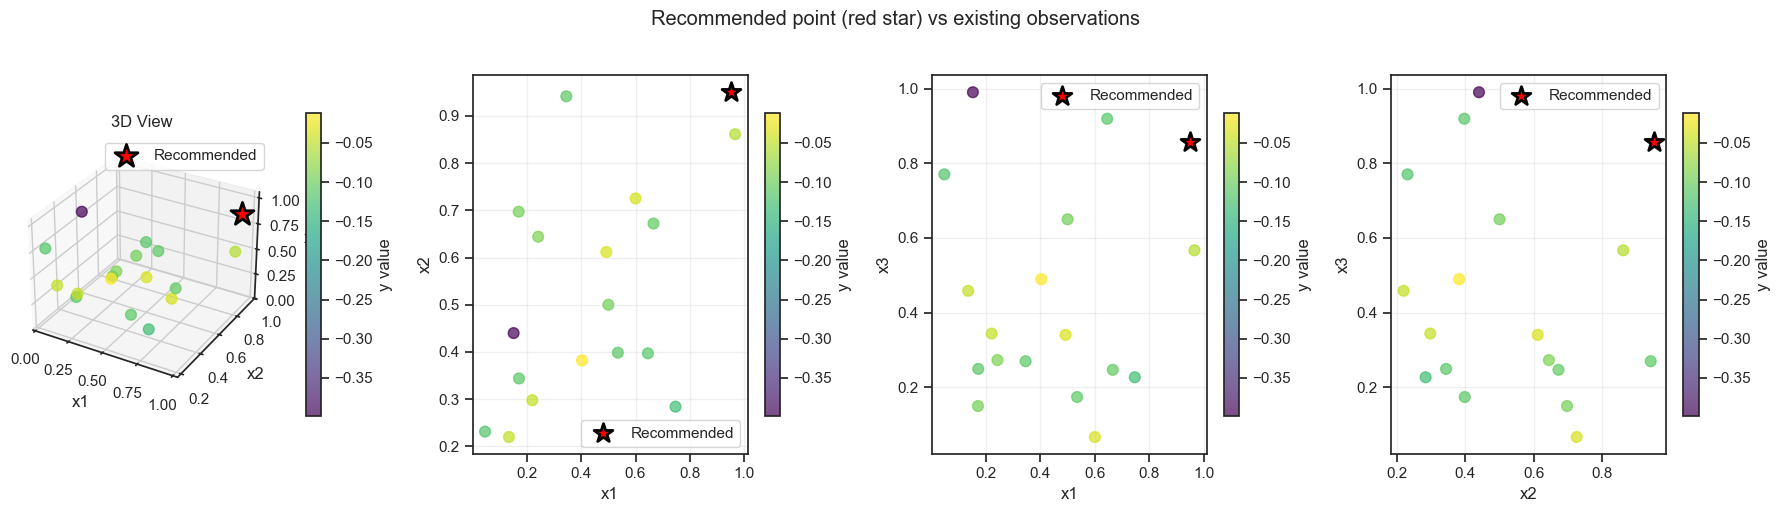

In [11]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(18, 5))
ax_3d = fig.add_subplot(141, projection='3d')
scatter_3d = ax_3d.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap="viridis", s=60, alpha=0.7)
ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
ax_3d.set_xlabel("x1")
ax_3d.set_ylabel("x2")
ax_3d.set_zlabel("x3")
ax_3d.legend()
ax_3d.set_title("3D View")
fig.colorbar(scatter_3d, ax=ax_3d, label="y value", shrink=0.8, pad=0.1)
axes = [fig.add_subplot(142), fig.add_subplot(143), fig.add_subplot(144)]
pairs = [(0, 1, "x1", "x2"), (0, 2, "x1", "x3"), (1, 2, "x2", "x3")]
for idx, (i, j, label_i, label_j) in enumerate(pairs):
    scatter2d = axes[idx].scatter(X[:, i], X[:, j], c=y, cmap="viridis", s=60, alpha=0.7)
    axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")
    axes[idx].set_xlabel(label_i)
    axes[idx].set_ylabel(label_j)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    plt.colorbar(scatter2d, ax=axes[idx], label="y value", shrink=0.8)
plt.suptitle("Recommended point (red star) vs existing observations", y=1.02)
plt.tight_layout()
plt.show()
